# Two Steps MultiFidelity Neural Network
## Hyperparameter Optimization
### Diffusion case

In [8]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from Multifidelity_support import getModel, kCrossVal, transfBestparam, import_data, normalization, add_noise, MultiFidelity
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf

In [9]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data Preparation

In [10]:
########################     PREPARATION      ##########################
# introduction of the data
file_path_LF = "../DATA/reaction_diffusion_LF_46_d75.mat"
(reaction_LF_test, U_LF_test) = import_data(file_path_LF)
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

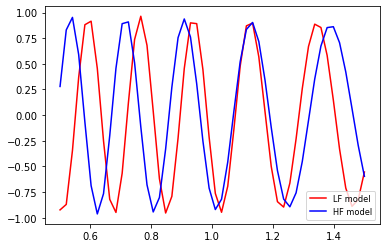

In [11]:
plt.figure()
plt.plot(reaction_LF_test, U_LF_test[
    :,
     - 1,
    12,12
], "r-", linewidth=1.5, label="LF model")
plt.plot(
    reaction_HF_test,
    U_HF_test[
    :,
     - 1,
    44,44
],
    "b-",
    markersize=7,
    label="HF model",
)
plt.legend(prop={"size": 8.3})
plt.show()

In [12]:
reaction_HF_test = normalization(reaction_HF_test)
U_HF_test = U_HF_test[:, -1, 44,44]
U_HF_test=normalization(U_HF_test)

reaction_HF_test_original=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]
U_HF_test_original=U_HF_test



reaction_LF_test = normalization(reaction_LF_test)
U_LF_test=U_LF_test[
    :,
     - 1,
    12,12
]
U_LF_test=normalization(U_LF_test)
reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
U_LF_test_original=U_LF_test


In [13]:
noise_stddev1=[0.01,0.005,0.02,0.005]
noise_stddev2=[0.005,0.003,0.01,0.003]

(U_HF_test,reaction_HF_test)=add_noise(noise_stddev1,noise_stddev2,reaction_HF_test,U_HF_test)
reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]

noise_std1=[0.02,0.01,0.02,0.01]
noise_std2=[0.01,0.005,0.01,0.005]

(U_LF_test,reaction_LF_test)=add_noise(noise_std1,noise_std2,reaction_LF_test,U_LF_test)
reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]


batch_size=[200,100]
Nepo=[7000,8000]


permutation = np.random.permutation(len(reaction_HF_test))
reaction_HF = reaction_HF_test[permutation,:][0:batch_size[1],:]
U_HF = U_HF_test[permutation][0:batch_size[1]]

permutation = np.random.permutation(len(reaction_LF_test))
reaction_LF = reaction_LF_test[permutation][0:batch_size[0],:]
U_train_LF = U_LF_test[permutation][0:batch_size[0]]

# Neural Network


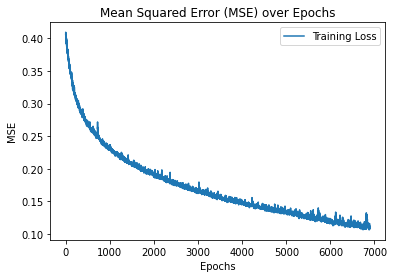

1/1 [==============================] - 0s 102ms/step 

1/1 [==============================] - 0s 27ms/step  

1/1 [==============================] - 0s 23ms/step  

1/1 [==============================] - 0s 42ms/step  

1/1 [==============================] - 0s 41ms/step  

1/1 [==============================] - 0s 27ms/step  

1/1 [==============================] - 0s 30ms/step  

1/1 [==============================] - 0s 21ms/step  

1/1 [==============================] - 0s 42ms/step  

1/1 [==============================] - 0s 17ms/step  

1/1 [==============================] - 0s 28ms/step  

1/1 [==============================] - 0s 42ms/step  

1/1 [==============================] - 0s 44ms/step  

1/1 [==============================] - 0s 35ms/step  

1/1 [==============================] - 0s 39ms/step  

1/1 [==============================] - 0s 39ms/step  

1/1 [==============================] - 0s 31ms/step  

1/1 [==============================] - 0s 34ms/step  

1/1 [=====

KeyboardInterrupt: 

In [14]:
K.clear_session()
names=["LF","2step"]

bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
}  # obtained

params=[bestLF_params]


model= MultiFidelity(names,params=params,data_train_LF=reaction_LF,output_train_LF=U_train_LF,data_train_HF=reaction_HF, output_train_HF=U_HF,N=Nepo,n=batch_size,verbose=False)
ULF = model.model_list[0].prediction(reaction_LF_test_original)

# U_LF_list.append(ULF)
# print("\nLF Model:")
print("low fidelity NN")
(test_mse_LF,r2_LF) = model.model_list[0].performance(reaction_LF_test_original,U_LF_test_original)

plt.figure()
plt.plot(
reaction_LF_test[:, 0], U_LF_test, "y-", linewidth=1.5, label="LF model"
)
plt.plot(
reaction_LF[:, 0],
U_train_LF,
"yo",
markersize=5,
label="LF training points",
)
plt.plot(
reaction_LF_test[:, 0],
model.model_list[0].prediction(reaction_LF_test),
"g-",
linewidth=3,
label="Predicted LF model",
)
plt.legend(prop={"size": 8.3})
plt.show()


input_HF = np.concatenate(
    (reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
)  # <- TRAINING INPUT for the second NN: NN_HF

input_HF_train = np.concatenate(
    (reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
) 

plt.figure()
plt.plot(
reaction_HF_test[:,0], U_HF_test, "r-", linewidth=1.5, label="HF model"
)
plt.plot(
input_HF_train[:, 0],
U_HF,
"ro",
markersize=5,
label="HF training points",
)


order=np.argsort(reaction_LF[:,0])

plt.plot(
reaction_LF[order,0],
U_train_LF[order],
"y-",
markersize=5,
label="LF training points",
)
plt.plot(
input_HF[:, 0],
model.model_list[1].prediction(input_HF),
"g-",
linewidth=3,
label="Predicted HF model",
)
plt.legend(prop={"size": 8.3})
plt.show()
